In [1]:
import os
import sys
import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgbm

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from utils import user_utils

In [7]:
raw_df = pd.read_csv('../data/creditcard.csv')
# raw_df.info()

In [2]:
def get_outlier(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
    
    # 사분위수 계산
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    # 이상치 마스크
    outlier_mask = pd.DataFrame(False, index=df.index, columns=columns)
    for col in columns:
        outlier_mask[col] = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    
    # 결과 요약
    outlier_bounds = pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": outlier_mask.sum()
    })
    
    return outlier_bounds


In [3]:
def get_outlier_idx(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
        
    fraud = df[df['Class']==1][columns]
    
    # 사분위수 계산
    Q1 = np.percentile(fraud.values, 25)
    Q3 = np.percentile(fraud.values, 75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    outlier_index = fraud[(fraud < lower_bound) | (fraud > upper_bound)].index
    return outlier_index

In [8]:
outlier_index = get_outlier_idx(raw_df, 'V16')

raw_df.iloc[outlier_index,:]['V16']

Series([], Name: V16, dtype: float64)

In [7]:
get_outlier(raw_df)

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
Time,54201.500000,139320.500000,85119.000000,-73477.000000,266999.000000,0
V1,-0.920373,1.315642,2.236015,-4.274396,4.669664,7062
V2,-0.598550,0.803724,1.402274,-2.701961,2.907135,13526
V3,-0.890365,1.027196,1.917560,-3.766705,3.903536,3363
V4,-0.848640,0.743341,1.591981,-3.236612,3.131313,11148
V5,-0.691597,0.611926,1.303524,-2.646882,2.567212,12295
V6,-0.768296,0.398565,1.166861,-2.518586,2.148856,22965
V7,-0.554076,0.570436,1.124512,-2.240844,2.257204,8948
V8,-0.208630,0.327346,0.535976,-1.012593,1.131309,24134
V9,-0.643098,0.597139,1.240237,-2.503452,2.457494,8283


In [9]:
raw_df.drop(['Time'], axis=1, inplace=True)
X_feature = raw_df.iloc[:,:-1]
y_label = raw_df.iloc[:,-1]

In [ ]:
# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_feature,
    y_label,
    test_size = 0.2,
    stratify = y_label,
    random_state = 42
)

In [6]:
catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,        # 학습률 (수치형 미세 패턴 학습을 위해 약간 낮춤)
    depth=6,
    l2_leaf_reg=3,             # L2 정규화 (수치형 데이터의 노이즈 과적합 방지)
    
    # *** 불균형 데이터 핵심 설정 ***
    # 방법 1: 자동 가중치 (추천)
    auto_class_weights='Balanced', 
    
    # 방법 2: 수동 가중치 계산 (참고용)
    # scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
    
    eval_metric='AUC',         # 평가 지표
    early_stopping_rounds=100, # 과적합 방지
    verbose=100,
    random_seed=23
)

gb_clf = GradientBoostingClassifier(
    n_estimators=100,      # 트리 개수
    learning_rate=0.1,     # 학습률
    max_depth=3,           # 개별 트리 깊이
    random_state=42
)

dt_clf = DecisionTreeClassifier(
    criterion="gini",   # 분할 기준 (gini, entropy)
    max_depth=None,     # 트리 최대 깊이 (None이면 제한 없음)
    random_state=42
)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=50,           # increase with early stopping if desired
    random_state=23
)

lr_clf = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = 23
)

In [30]:
# user_utils.get_model_train_eval(catboost,'rawdata_catboost_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(gb_clf,'rawdata_gb_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(dt_clf,'rawdata_dt_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(mlp_clf,'rawdata_mlp_20251126',X_train,X_test,y_train,y_test)
user_utils.get_model_train_eval(lr_clf,'rawdata_lr_20251126',X_train,X_test,y_train,y_test)

✓ 모델 저장 완료: ../models\rawdata_lr_20251126.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9892, 정확도: 0.9683, 정밀도: 0.0486, 재현율: 0.9388, F1: 0.0924
오차행렬:
[[55062  1801]
 [    6    92]]
실행 시간: 1.055069923400879


In [10]:
amount_n = np.log1p(raw_df['Amount'])
raw_df.insert(0,'Amount Scaled', amount_n)
raw_df.drop(['Amount'], axis=1, inplace=True)
# outlier_index = get_outlier_idx(raw_df, 'V14')
# raw_df.drop(outlier_index, axis=0, inplace=True)
# raw_df

In [10]:
raw_df.to_csv('../data/scaledAmount_data.csv',index=False)

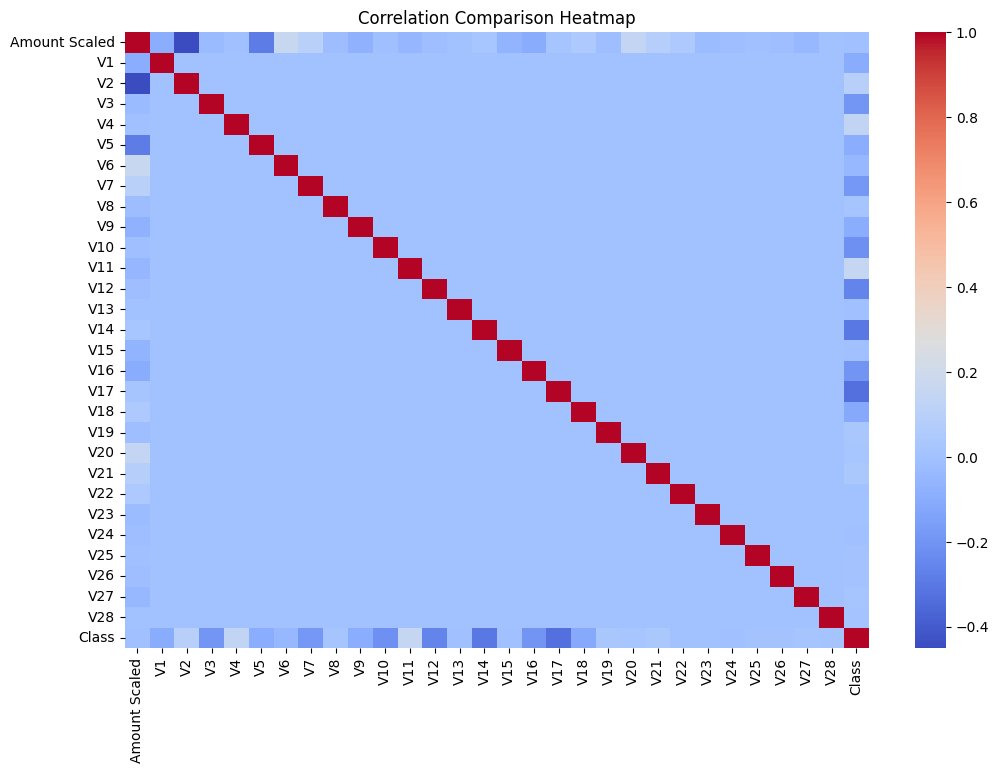

In [17]:
columns = raw_df.select_dtypes(include="number").columns
corr_matrix = raw_df[columns].corr()
    
    # 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Comparison Heatmap")
plt.show()


In [4]:
def cap_outliers(df, columns=None, weight=1.5):
    """
    IQR 기반으로 이상치를 탐지하고 상한/하한 값으로 대체(Capping)하는 함수.
    
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    df_capped = df.copy()
    
    # 처리할 컬럼 선택
    if columns is None:
        columns = df_capped.select_dtypes(include=np.number).columns
    
    for col in columns:
        # 사분위수 및 IQR 계산
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 이상치 경계 계산
        lower_bound = Q1 - weight * IQR
        upper_bound = Q3 + weight * IQR
        
        # Capping 적용
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

In [21]:
scaled_df = pd.read_csv('../data/scaledAmount_data.csv')


In [22]:
temp_X_feature = scaled_df.iloc[:,:-1]
y_label = scaled_df.iloc[:,-1]
# temp_X_feature = raw_df.iloc[:,:-1]
# y_label = raw_df.iloc[:,-1]

X_feature = cap_outliers(temp_X_feature)

In [26]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_feature, y_label)

print("\n--- SMOTE 오버샘플링 후 ---")
print(y_resampled.value_counts())


--- SMOTE 오버샘플링 후 ---
Class
0    284315
1    284315
Name: count, dtype: int64


In [27]:
# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size = 0.2,
    random_state = 42
)

In [28]:
import joblib

model = joblib.load("../models/ovesample_capped_mlp_ejm.pkl")
y_pred_proba = model.predict_proba(X_test)[:,1]


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def plot_threshold_curve(y_true, y_pred_proba, save_path="../report/threshold_curve.png"):
    thresholds = np.linspace(0.0, 1.0, 101)
    
    precisions = []
    recalls = []
    f1_scores = []

    for t in thresholds:
        y_pred = (y_pred_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_true, y_pred, zero_division=0))

    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, precisions, label='Precision', color='blue')
    plt.plot(thresholds, recalls, label='Recall', color='green')
    plt.plot(thresholds, f1_scores, label='F1 Score', color='red')

    # Optimal threshold by maximizing F1
    best_idx = np.argmax(f1_scores)
    best_t = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    plt.axvline(best_t, color='gray', linestyle='--', label=f'Best F1 Threshold = {best_t:.2f}')
    plt.title("Threshold 변화에 따른 Precision / Recall / F1 Score 곡선", fontsize=14)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"📌 Threshold Curve 저장 완료 → {save_path}")
    print(f"⭐ 최고 F1 값을 주는 임계값: {best_t:.3f}, F1 = {best_f1:.4f}")

    return {
        "best_threshold": best_t,
        "best_f1": best_f1,
        "precisions": precisions,
        "recalls": recalls,
        "f1_scores": f1_scores
    }


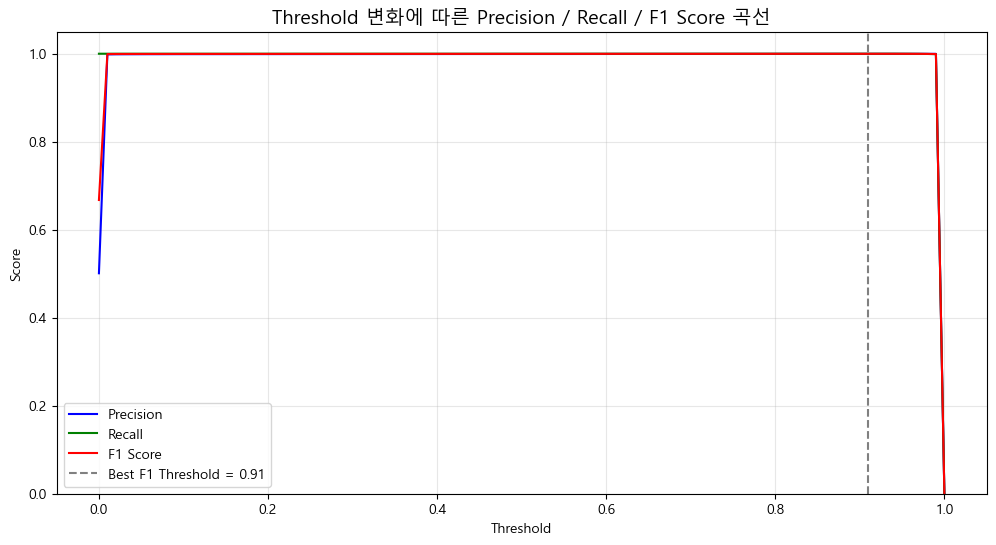

📌 Threshold Curve 저장 완료 → ../report/threshold_curve_over.png
⭐ 최고 F1 값을 주는 임계값: 0.910, F1 = 0.9998


In [30]:
result = plot_threshold_curve(y_test, y_pred_proba, save_path="../report/threshold_curve_over.png")



---
# ✔ 이미 만든 그래프 (제외 대상)
현재까지 생성 완료된 그래프는 다음 5개이다:
1. 전체 모델 지표 Boxplot
2. 모델별 핵심 지표 Heatmap (Top10)
3. Radar Chart (Top5)
4. Threshold 변화에 따른 Precision/Recall/F1 Curve
5. F1 기준 Top10 Bar Chart
→ **이 5가지는 제외하고**, Feature Importance 파트에 추천했던 나머지 이미지들만 다시 정리한다.

---

# ✔ 3.5.2 Feature Importance 분석에서 활용 가능한 이미지 후보 (이전에 추천했던 목록)

## **A. Permutation Importance 그래프**

### 1) 상위 20개 Feature Importance Bar Chart

* MLP 같은 계산 그래프 모델은 직접 feature importance가 없기 때문에
  permutation 기반 importance가 가장 적합함
* 표준적으로 가장 많이 사용되는 시각화

**추천 그래프 예:**

* Horizontal Bar Plot (높은 중요도가 위로 오도록)
* Error bar 포함 버전도 가능

---

## **B. SHAP 기반 설명 그래프**

신용카드 사기 탐지 데이터는 PCA 기반 V-feature라 SHAP이 특히 잘 맞음.

### 2) SHAP Summary Plot (Bee Swarm Plot)

* 모든 특성이 전체 예측에 얼마나 영향을 미쳤는지 직관적으로 확인
* 3.5.2.1 “주요 특성 상위 10개”와 바로 연결됨
* 가장 대표적인 모델 해석 이미지

### 3) SHAP Bar Plot (mean |SHAP value| 기준 Top 20)

* Summary는 분포 기반
* Bar Plot은 **중요도의 평균적 크기**를 보여주기 때문에 보고서에서 해석하기 좋음

### 4) SHAP Dependence Plot (Top 3 피처 개별 분석)

* 예: V14 vs SHAP value
* 값이 커질 때 어떤 방향으로 예측이 이동하는지 시각적으로 명확
* V-feature는 해석이 어렵기 때문에 이 그래프가 설명에 큰 도움이 됨

---

## **C. Partial Dependence Plot (PDP) / ICE Plot**

### 5) PDP Plot (Top 3 Feature)

* SHAP보다 간단하게 “특성 값이 증가하면 사기 확률이 어떻게 변화하는지”를 보여줌
* 단일 모델의 국소/전체 패턴 설명에 매우 효과적

### 6) ICE Plot (개별 데이터 반응)

* PCA 기반 feature라 개별 샘플 반응이 다양함 → ICE가 그 다양성을 보여줄 수 있음

---

## **D. Correlation Heatmap (V-FEATURE 간 상관 분석)**

### 7) 상위 중요도 피처 10개의 상관행렬 히트맵

* PCA 기반 V-feature는 서로 높은 상관을 갖기도 한다
* 어떤 feature cluster가 사기 패턴을 설명하는지 파악 가능

---

# ✔ “Feature Importance 통합 분석”용으로 가장 추천하는 세트

보고서용 최적 추천 세트는 다음 4가지:

1. **Permutation Importance Top 20 Bar Chart**
2. **SHAP Summary Plot (Bee Swarm)**
3. **SHAP Bar Plot (mean |SHAP|)**
4. **SHAP Dependence Plot (Top 1 or Top 3)**

이 4개면 **3.5.2 Feature Importance 분석 섹션이 매우 풍성하고 전문적인 구성**이 된다.


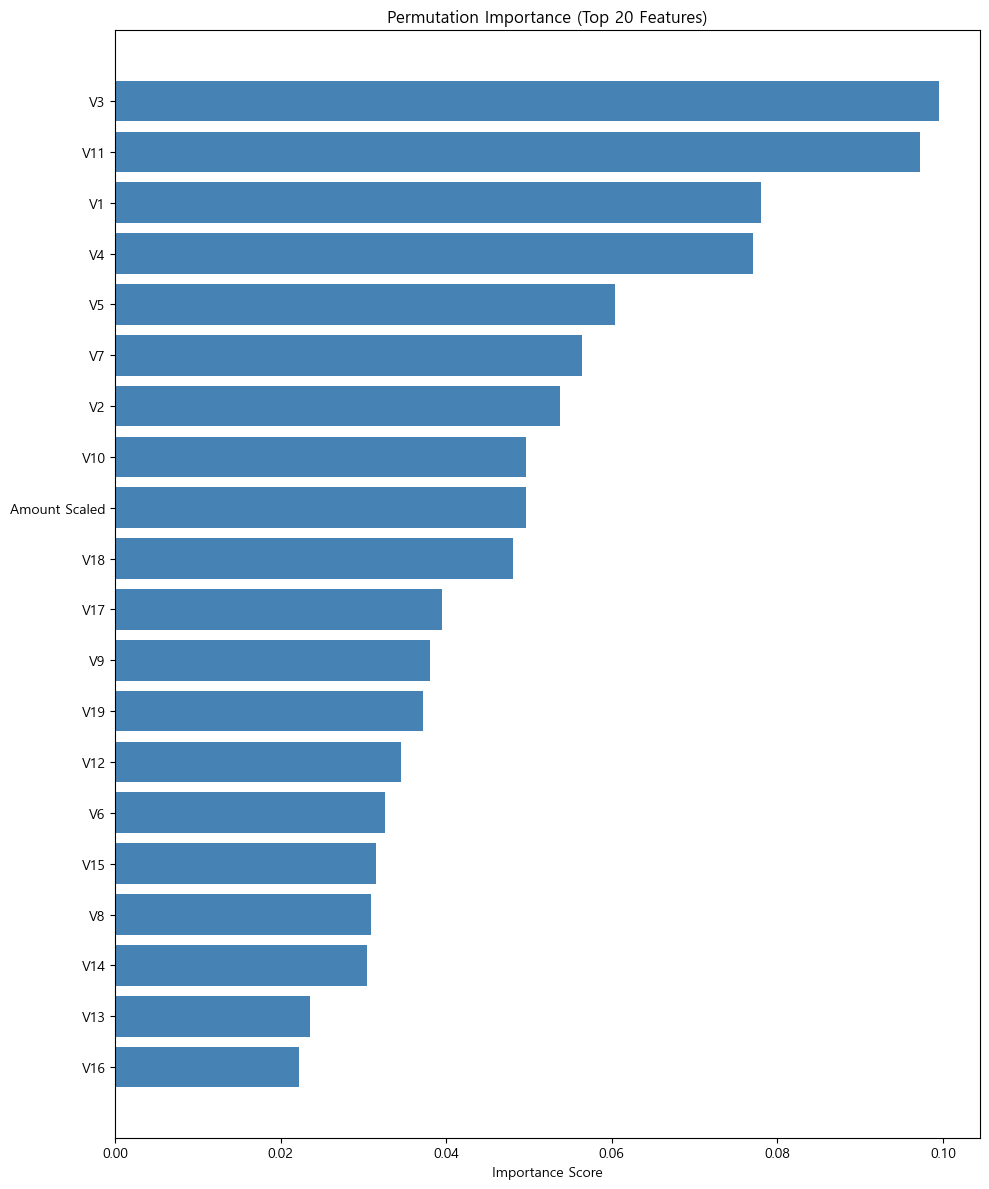

In [31]:
import pickle
from sklearn.inspection import permutation_importance

# ---------------------------------------------
# Load Model
# ---------------------------------------------
model_path = "../models/ovesample_capped_mlp_ejm.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

# X, y 는 사용자가 준비한 데이터프레임
# 예: X = df.drop("Class", axis=1); y = df["Class"]

# ---------------------------------------------
# Permutation Importance 계산
# ---------------------------------------------
result = permutation_importance(
    model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

top20 = importances.head(20)

# ---------------------------------------------
# 1) Permutation Importance Top 20 이미지
# ---------------------------------------------
plt.figure(figsize=(10, 12))
plt.barh(top20["feature"], top20["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Top 20 Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../report/feature_perm_top20.png", dpi=200)
plt.show()


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 200/200 [01:33<00:00,  2.14it/s]


X_sample: (200, 29)
shap_values: (200, 29)


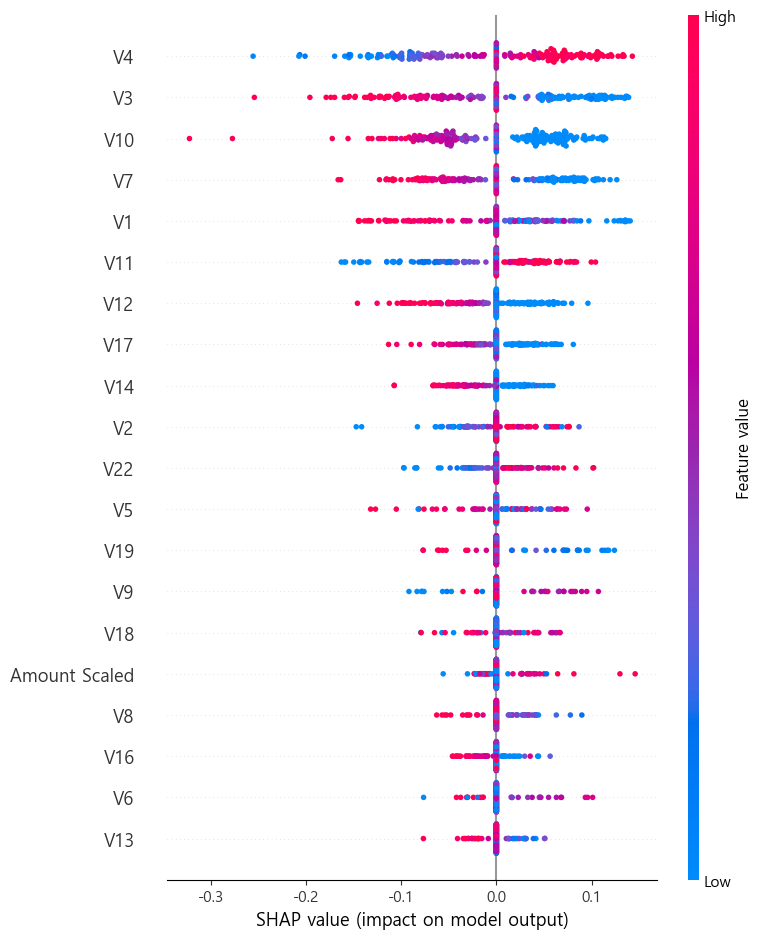

In [34]:
# 2) SHAP Summary Plot 이미지 생성
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1) 샘플링
X_sample = X_train.sample(200, random_state=23)

# 2) SHAP explainer - 반드시 positive class prob만 전달
explainer = shap.KernelExplainer(
    lambda x: model.predict_proba(x)[:, 1],
    X_sample
)

# 3) SHAP 값 계산
shap_values = explainer.shap_values(X_sample)

print("X_sample:", X_sample.shape)
print("shap_values:", np.array(shap_values).shape)

# 4) summary plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, feature_names=X_sample.columns, show=False)
plt.tight_layout()
plt.savefig("../report/shap_summary.png", dpi=300)
plt.show()





Saved: shap_bar.png


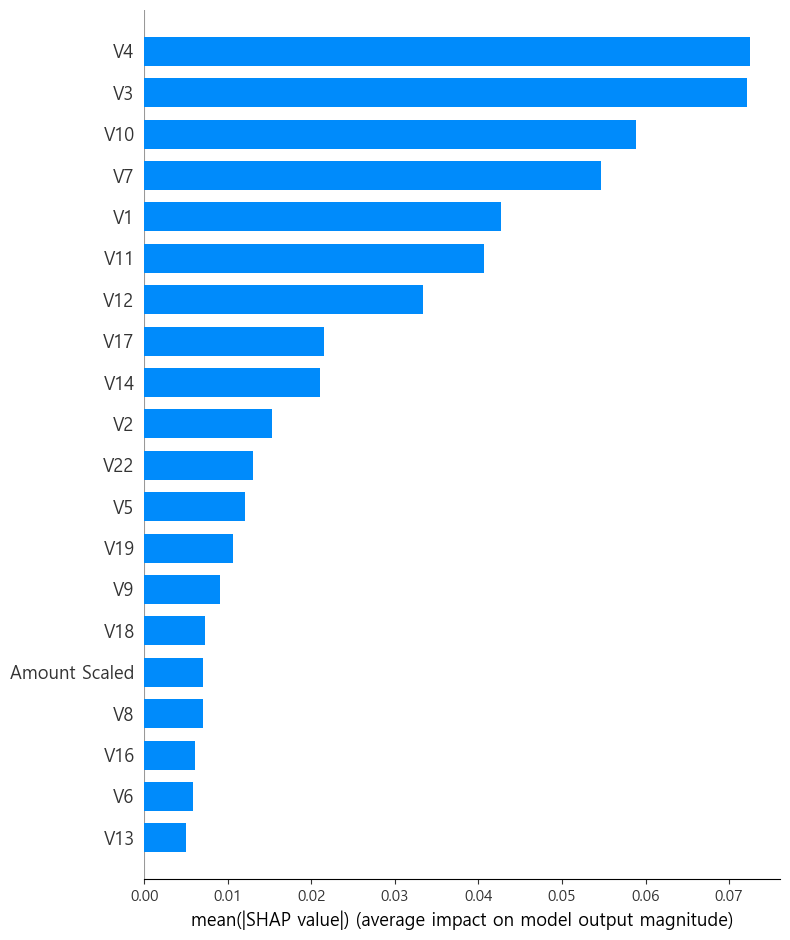

In [35]:
# 3) SHAP Bar Plot (mean |SHAP value| Top 20)
plt.figure(figsize=(10,10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", feature_names=X_sample.columns, show=False)
plt.tight_layout()
plt.savefig("../report/shap_bar.png", dpi=300)
print("Saved: shap_bar.png")
plt.show()



Top 3 features: Index(['V10', 'V3', 'V4'], dtype='object')


<Figure size 800x600 with 0 Axes>

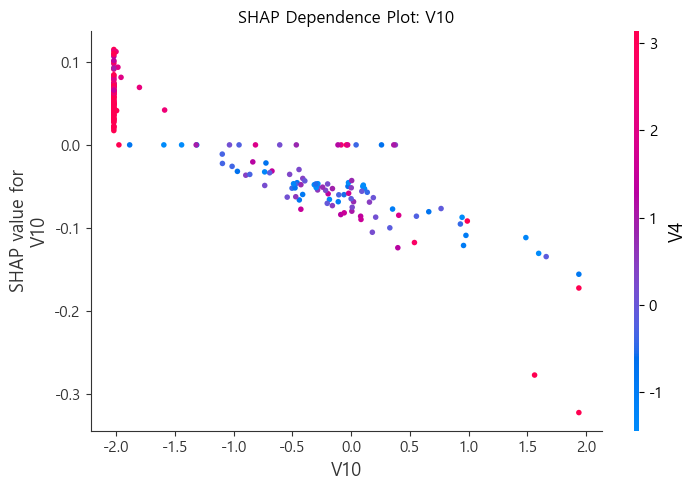

<Figure size 800x600 with 0 Axes>

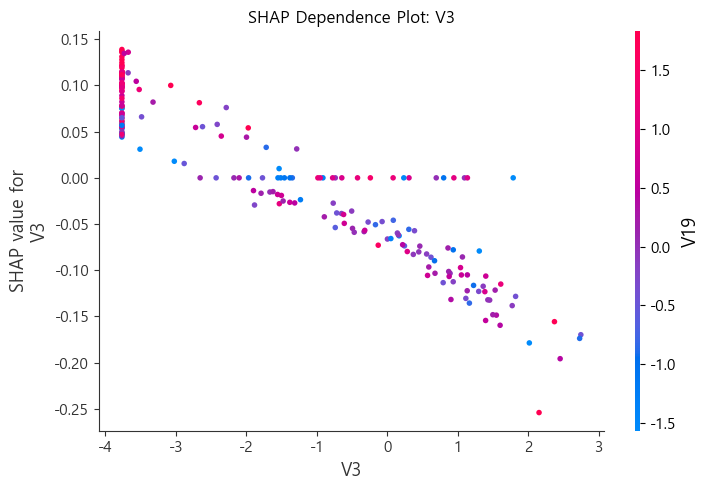

<Figure size 800x600 with 0 Axes>

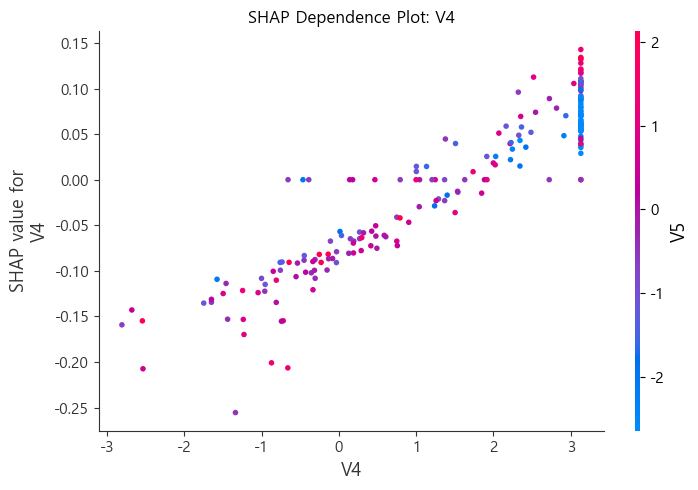

In [36]:
# 4) SHAP Dependence Plot (Top Feature 1~3개)

# 1) Top 3 important features
top_features = X_sample.columns[np.argsort(np.abs(shap_values).mean(axis=0))][-3:]

print("Top 3 features:", top_features)

# 2) Create dependence plots
for feature in top_features:
    plt.figure(figsize=(8,6))
    shap.dependence_plot(
        feature, 
        shap_values,            # shap_values: (200,29)
        X_sample,               # same X used for SHAP
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feature}")
    plt.tight_layout()
    plt.savefig(f"../report/shap_depend_{feature}.png", dpi=200)
    plt.show()
    plt.close()

